titanic data setinde XGBoots ve LightGBM algoritmalarını kullanarak model eğitim yapıyoruz. EDA kısmında "deck","embark_town","alive" kolonlarını drop yapıp, null degerlei mood ve medyan ile dolduryoruz. ardından encoding ve hyperparameter tuning ile en uygun parametreyi belirliyoruz.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sympy import true

In [2]:
df =pd.read_csv("titanic.csv")

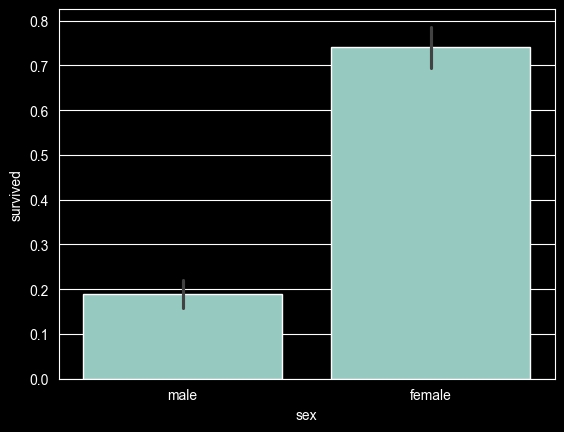

In [3]:
sns.barplot(x='sex', y='survived', data=df)
plt.show()

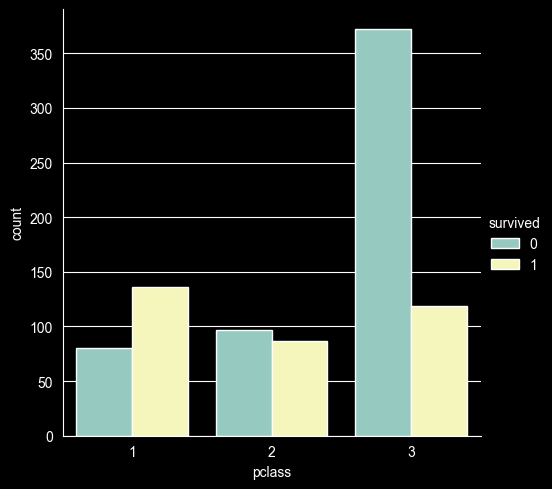

In [4]:
sns.catplot(data=df,x="pclass", hue="survived", kind="count")
plt.show()

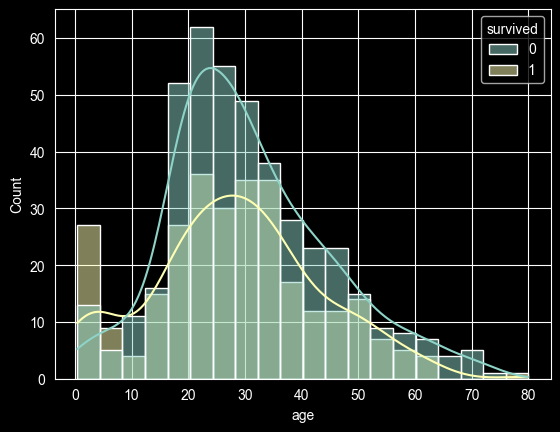

In [5]:
sns.histplot(data=df,x="age", hue="survived",kde=True)
plt.show()

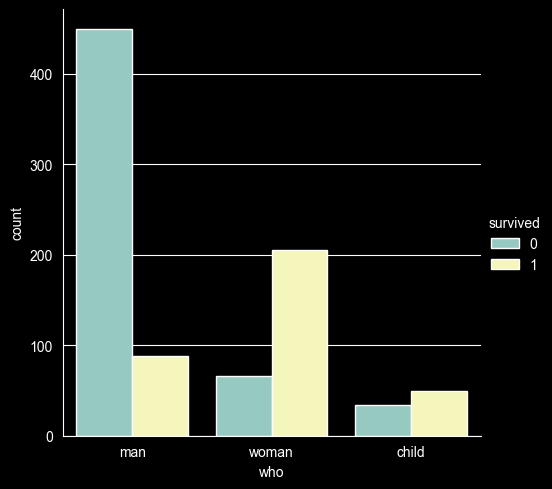

In [6]:
sns.catplot(data=df,x="who",hue="survived",kind="count")
plt.show()

In [7]:
df.shape


(891, 15)

In [8]:
df.info(
)

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


In [9]:
df.isnull().sum().sort_values() #deck kolonu silinceke

survived         0
pclass           0
sex              0
sibsp            0
parch            0
fare             0
class            0
who              0
adult_male       0
alive            0
alone            0
embarked         2
embark_town      2
age            177
deck           688
dtype: int64

In [10]:
df=df.drop(["deck","embark_town","alive"], axis=1)

In [11]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [12]:
df["age"]=df["age"].fillna(df["age"].mean())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0]) # mod dizi şeklinde döndüğü için 1. elemanını alıyoruz.

In [13]:
# let's convert bool dtypes into 0s and 1s
df['adult_male'] = df['adult_male'].astype(int)
df['alone'] = df['alone'].astype(int)

In [14]:
X = df.drop('survived', axis=1)
y = df['survived']

In [15]:

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 15)

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_cols = ['sex', 'class', 'who','embarked']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)


In [17]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [18]:
encoded_cols = preprocessor.get_feature_names_out()

In [19]:
# Making X_train and X_test pandas dataframes so that we can use them later if we need anything else than training
X_train = pd.DataFrame(X_train, columns = encoded_cols)
X_test = pd.DataFrame(X_test, columns = encoded_cols)
X_train.head()

,cat__sex_male,cat__class_Second,cat__class_Third,cat__who_man,cat__who_woman,cat__embarked_Q,cat__embarked_S,remainder__pclass,remainder__age,remainder__sibsp,remainder__parch,remainder__fare,remainder__adult_male,remainder__alone
0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,3.0,27.000000,0.0,0.0,7.8958,1.0,1.0
1,0.0,1.0,0.0,0.0,1.0,0.0,1.0,2.0,17.000000,0.0,0.0,10.5000,0.0,1.0
2,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,29.699118,0.0,0.0,0.0000,1.0,1.0
3,1.0,0.0,1.0,1.0,0.0,0.0,1.0,3.0,26.000000,0.0,0.0,8.0500,1.0,1.0
4,1.0,0.0,1.0,1.0,0.0,0.0,1.0,3.0,43.000000,0.0,0.0,8.0500,1.0,1.0


In [20]:
import lightgbm as lgb

In [21]:
from sklearn.metrics import classification_report, confusion_matrix
clf = lgb.LGBMClassifier(verbosity=-1)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(classification_report(y_pred,y_test))
print(confusion_matrix(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.82      0.82      0.82       127
           1       0.76      0.76      0.76        96

    accuracy                           0.79       223
   macro avg       0.79      0.79      0.79       223
weighted avg       0.79      0.79      0.79       223

[[104  23]
 [ 23  73]]


In [22]:
clf.feature_importances_

array([  60,   33,   52,   26,   29,   30,   80,   11,  871,   81,   72,
       1141,    0,   40], dtype=int32)

In [23]:
from sklearn.model_selection import RandomizedSearchCV

lgb_model = lgb.LGBMClassifier(verbosity=-1)

param_grid = {
    'n_estimators': [100, 300, 500, 1000],
    'max_depth': [3, 5, 7, -1],
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'num_leaves': [15, 31, 63, 127],
    'min_child_samples': [5, 10, 20],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# Randomized search
random_search = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=param_grid,
    scoring='accuracy',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMClassifier(verbosity=-1)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'min_child_samples': [5, 10, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be use

In [24]:
random_search.best_params_

{'subsample': 0.6,
 'num_leaves': 63,
 'n_estimators': 100,
 'min_child_samples': 5,
 'max_depth': 5,
 'learning_rate': 0.05,
 'colsample_bytree': 1.0}

In [26]:
y_pred=random_search.predict(X_test)

In [27]:
print(classification_report(y_pred,y_test))
print(confusion_matrix(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.89      0.83      0.86       136
           1       0.76      0.84      0.80        87

    accuracy                           0.83       223
   macro avg       0.83      0.83      0.83       223
weighted avg       0.84      0.83      0.84       223

[[113  23]
 [ 14  73]]


In [29]:
from xgboost import XGBClassifier
xgb=XGBClassifier(n_estimators=100)
xgb.fit(X_train, y_train)
y_pred=xgb.predict(X_test)
print(classification_report(y_pred,y_test))
print(confusion_matrix(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.83      0.79      0.81       134
           1       0.71      0.76      0.74        89

    accuracy                           0.78       223
   macro avg       0.77      0.78      0.77       223
weighted avg       0.78      0.78      0.78       223

[[106  28]
 [ 21  68]]
